# EDA — TON_IoT (telemetria)

Análise exploratória das 7 subbases de telemetria do **TON_IoT** (UNSW
Canberra Cyber), pensada pra servir de **rascunho técnico** para os
integrantes do trabalho. Cobre:

- Estrutura dos CSVs e limpeza obrigatória (§1).
- Features numéricas vs categóricas e quantos bits cada base gera (§3).
- Balanço de classes binário e multi-classe (§4).
- **Descoberta importante** sobre estrutura temporal do dataset (§5)
  — `date` e `time` são data leakage e devem ser excluídos.
- Distribuições, pares de features, correlações (§6–8).
- Codificação binária pras WNNs: termômetros lado-a-lado e preview
  do bit-pattern (§9).
- **Rascunho de utilitários** com funções prontas pro `sweep_utils.py`
  + exemplo end-to-end treinando um WiSARD real (§10).

Pra discussão de objetivos, métricas e divisão entre integrantes,
ver **`PLANO.md`** na mesma pasta.

## 0. Setup

In [1]:
import os
import json
import time
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_NORMAL = '#4C78A8'
COLOR_ATTACK = '#E45756'
COLOR_NEUTRAL = '#888888'
# paleta consistente para tipos de ataque (10 cores — cobre os 9 ataques + normal)
ATTACK_PALETTE = {
    'normal':     '#4C78A8',
    'ddos':       '#E45756',
    'backdoor':   '#F58518',
    'injection':  '#B279A2',
    'password':   '#9D755D',
    'ransomware': '#54A24B',
    'scanning':   '#EECA3B',
    'xss':        '#72B7B2',
    'mitm':       '#FF9DA6',
    'dos':        '#BAB0AC',
}

DATA_DIR = Path('../../data/toniot/')
RESULTS_DIR = Path('./results/')

EXPECTED = [
    'Fridge', 'Garage_Door', 'GPS_Tracker', 'Modbus',
    'Motion_Light', 'Thermostat', 'Weather',
]

## 0.1 Mini-crash-course de WiSARD pros colegas

Pra quem nao mexeu com WNNs antes: este parágrafo vale 5 minutos
de leitura e cobre o que vc precisa pra entender o que esse notebook
mede.

- **WiSARD** eh um classificador que substitui "neuronio" por **RAM**.
  Entrada eh binaria (uma sequencia de bits). Cada classe tem N RAMs,
  cada uma le `addressSize` bits da entrada (escolhidos por um mapping
  aleatorio fixo) e usa esses bits como endereco. Treino = escrever
  1 (ou contador++) na entrada apontada. Inferencia = somar quantas
  RAMs respondem por classe; a classe com mais votos vence.
- **Termometro**: como converter `float` em bits. Termometro de
  tamanho 8 produz 8 bits por feature; "bits acesos" cresce
  monotonicamente com o valor. Tipos variam em **onde** os
  thresholds caem (uniforme, quantis, etc) — ver §9.1.
- **AddressSize / tupleSize**: bits por RAM. Mais bits = endereco
  maior = mais RAMs precisariam ser tocadas (cresce exponencialmente).
  Tem que ser **<= bits totais da entrada**. Ver §9.3.
- **Bleaching** (`BBleaching`): threshold de "quantas RAMs precisam
  responder pra contar voto". Ajuste pos-treino, melhora muito.
- **wisardpkg**: implementacao C++ com bindings Python. APIs principais
  usadas neste notebook:
  - `wp.SimpleThermometer / DistributiveThermometer / GaussianThermometer / ExponentialThermometer`
  - `wp.DataSet(X_lists, y_strings)` para empacotar inputs+labels
  - `wp.Wisard(addressSize)`, `.train(ds)`, `.classify(ds)`, `.rank(ds)`
  - `.json()` serializa o modelo (usamos pra medir memoria)


## 0.2 Reprodutibilidade

- Random seed: 0 (split + RandomMapping do WiSARD)
- Train/test: 70/30 estratificado por `type`
- Politica de bits: ver `cat_encoded_bits()` em §3
- Versoes: `wisardpkg 2.0.0a7` (fork local), Python 3.13, pandas 2.x
- Plataforma de tempo (`train_time_s`, `inference_latency_us`):
  **soh comparavel intra-maquina** — pra cross-integrante, todos
  precisam rodar no mesmo Colab (ou normalizar por config de referencia
  conforme PLANO §2.4). O campo `machine` no result JSON registra isso.


## 1. Carregar e limpar os 7 CSVs

A limpeza é a parte sutil — pandas 2.x lê strings como `StringDtype`,
não `object`. Sem strip+lowercase explícito, várias colunas aparentam
ter mais categorias do que têm de verdade:

- `temp_condition` aparece como 6 categorias (`'high'`, `'high '`,
  `'high  '`...) quando tem 2.
- `sphone_signal` mistura `'0'`, `'1'`, `'false  '`, `'true  '`.
- `light_status` vem com espaço (`' on'`, `' off'`).
- `date` tem trailing space — quebra o parse de timestamp.

`clean_df()` resolve tudo de uma vez. **A mesma função tem que rodar
no sweep** — fica em `sweep_utils.py` (§10).

In [2]:
def clean_df(df):
    """Normaliza um CSV TON_IoT recém-carregado.

    - lowercase + strip nos nomes de colunas
    - strip + lowercase em todas as colunas nao-numericas
    - sphone_signal {'0','1','false','true'} -> Int64 {0,1}
    - label como Int64
    """
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype(str).str.strip().str.lower()
    if 'sphone_signal' in df.columns:
        df['sphone_signal'] = (df['sphone_signal']
                               .map({'0': 0, '1': 1, 'false': 0, 'true': 1})
                               .astype('Int64'))
    if 'label' in df.columns:
        df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
    return df


def find_csv(device):
    if not DATA_DIR.exists():
        return None
    target = f'train_test_iot_{device}.csv'.lower()
    for p in DATA_DIR.iterdir():
        if p.name.lower() == target:
            return p
    return None


dfs = {}
missing = []
for device in EXPECTED:
    p = find_csv(device)
    if p is None:
        missing.append(device)
        continue
    dfs[device] = clean_df(pd.read_csv(p))

print(f'Carregadas {len(dfs)} / {len(EXPECTED)} bases.')
for device, df in dfs.items():
    print(f'  {device:<13}  {df.shape[0]:>6,} x {df.shape[1]}  ({find_csv(device).stat().st_size/1e6:.1f} MB)')
if missing:
    print(f'\nFALTANDO: {missing}')
    print(f'Esperado em: {DATA_DIR.resolve()}')
DATA_AVAILABLE = len(dfs) == len(EXPECTED)
assert DATA_AVAILABLE, 'Faltam CSVs — ver README.md'

Carregadas 0 / 7 bases.

FALTANDO: ['Fridge', 'Garage_Door', 'GPS_Tracker', 'Modbus', 'Motion_Light', 'Thermostat', 'Weather']
Esperado em: /home/renan/Git/masters/data/toniot


AssertionError: Faltam CSVs — ver README.md

### 1.1 Sanity da limpeza

Conta categorias distintas em cada coluna string, antes e depois do
`clean_df`. As 4 colunas mostradas embaixo iam para o encoder com
cardinalidade inflada se a limpeza não rodasse.

In [ ]:
rows = []
for device in ['Fridge', 'Garage_Door', 'Motion_Light']:
    raw = pd.read_csv(find_csv(device))
    cleaned = clean_df(raw)
    for c in raw.columns:
        if raw[c].dtype == object or pd.api.types.is_string_dtype(raw[c]):
            cn = c.strip().lower()
            if cn in cleaned.columns:
                rows.append({
                    'device': device,
                    'coluna': cn,
                    'cardinalidade_raw': raw[c].nunique(),
                    'cardinalidade_clean': cleaned[cn].nunique(),
                })
print(pd.DataFrame(rows).to_string(index=False))

      device         coluna  cardinalidade_raw  cardinalidade_clean
      Fridge           date                  8                    8
      Fridge           time              17860                17197
      Fridge temp_condition                  6                    2
      Fridge           type                  7                    7
 Garage_Door           date                  8                    8
 Garage_Door           time              17205                17011
 Garage_Door     door_state                  2                    2
 Garage_Door  sphone_signal                  4                    2
 Garage_Door           type                  8                    8
Motion_Light           date                  7                    7
Motion_Light           time              22152                20290
Motion_Light   light_status                  2                    2
Motion_Light           type                  8                    8


## 2. Visão geral por base

Shape, dtypes e duas linhas de exemplo. As bases têm de **6 a 8 colunas**
totais (incluindo `date`, `time`, `label`, `type`).

In [ ]:
for device, df in dfs.items():
    print('=' * 78)
    print(f'{device}  —  {df.shape[0]:,} linhas  x  {df.shape[1]} colunas')
    print('-' * 78)
    print(df.dtypes.to_string())
    print('-- amostra --')
    print(df.head(2).to_string(index=False))
    print()

Fridge  —  39,944 linhas  x  6 colunas
------------------------------------------------------------------------------
date                      str
time                      str
fridge_temperature    float64
temp_condition            str
label                   Int64
type                      str
-- amostra --
     date     time  fridge_temperature temp_condition  label type
25-apr-19 19:19:40                9.00           high      1 ddos
25-apr-19 19:19:40                9.25           high      1 ddos

Garage_Door  —  39,587 linhas  x  6 colunas
------------------------------------------------------------------------------
date               str
time               str
door_state         str
sphone_signal    Int64
label            Int64
type               str
-- amostra --
     date     time door_state  sphone_signal  label type
25-apr-19 14:42:33     closed              0      1 ddos
25-apr-19 14:42:38     closed              0      1 ddos

GPS_Tracker  —  38,960 linhas  x  6 coluna

## 3. Features: numéricas vs categóricas

WNNs precisam de entrada binária. **Termômetros** codificam features
numéricas; **one-hot** codifica categóricas. As contagens abaixo
dimensionam quantos bits cada base vai gerar — esse número limita o
`addressSize` admissível (não pode ter RAM com mais bits do que a
entrada tem).

`META_COLS` (`date`, `time`, `label`, `type`) **não entra** no encoder:
- `label` e `type` são alvos.
- `date`/`time` são data leakage (ver §5).

In [ ]:
META_COLS = {'date', 'time', 'label', 'type'}


def feature_cols(df):
    """Separa as features em (numericas, categoricas)."""
    num, cat = [], []
    for c in df.columns:
        if c in META_COLS:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            num.append(c)
        else:
            cat.append(c)
    return num, cat


def cat_encoded_bits(unique_values):
    """Bits gastos por uma feature categorica:
    - 2 valores (binaria) -> 1 bit
    - k valores (k>2)     -> k bits (one-hot)

    One-hot pra binaria gera dois bits perfeitamente anti-correlacionados:
    informacao redundante e desperdicio de orcamento de entrada na WNN.
    Como o mapping aleatorio pode jogar os dois bits redundantes na mesma
    tupla, eles formariam um invariante constante (b XOR ~b = 1) que
    desperdica capacidade de RAM.
    """
    return 1 if len(unique_values) == 2 else len(unique_values)


rows = []
for device, df in dfs.items():
    num, cat = feature_cols(df)
    cat_card = sum(cat_encoded_bits(df[c].unique()) for c in cat)
    rows.append({
        'device': device,
        'n_rows': len(df),
        'num': len(num),
        'cat': len(cat),
        'card': cat_card,
        'bits@T8':  len(num) *  8 + cat_card,
        'bits@T16': len(num) * 16 + cat_card,
        'bits@T32': len(num) * 32 + cat_card,
        'bits@T64': len(num) * 64 + cat_card,
    })
feat_df = pd.DataFrame(rows)
print(feat_df.to_string(index=False))
print()
print('Features por base:')
for device, df in dfs.items():
    n, c = feature_cols(df)
    print(f'  {device:<13}  num={n}   cat={c}')
print()
print('Politica de bits categoricos:')
print('  - Categorica binaria (high/low, on/off, open/closed) -> 1 bit')
print('  - Categorica k-aria com k>2                          -> k bits (one-hot)')
print('  No TON_IoT telemetria todas as categoricas sao binarias,')
print('  entao economizamos 1 bit por categorica vs one-hot ingenuo.')


      device  n_rows  num  cat  card  bits@T8  bits@T16  bits@T32  bits@T64
      Fridge   39944    1    1     1        9        17        33        65
 Garage_Door   39587    1    1     1        9        17        33        65
 GPS_Tracker   38960    2    0     0       16        32        64       128
      Modbus   31106    4    0     0       32        64       128       256
Motion_Light   39488    1    1     1        9        17        33        65
  Thermostat   32774    2    0     0       16        32        64       128
     Weather   39260    3    0     0       24        48        96       192

Features por base:
  Fridge         num=['fridge_temperature']   cat=['temp_condition']
  Garage_Door    num=['sphone_signal']   cat=['door_state']
  GPS_Tracker    num=['latitude', 'longitude']   cat=[]
  Modbus         num=['fc1_read_input_register', 'fc2_read_discrete_value', 'fc3_read_holding_register', 'fc4_read_coil']   cat=[]
  Motion_Light   num=['motion_status']   cat=['light_sta

**Pontos importantes**:

- Bases **pobres em features**: Fridge, Garage_Door, Motion_Light têm
  apenas 1 numérica + 1 categórica (2 entradas), gerando só 10 bits
  com termômetro=8. Pra essas, `addressSize` máximo válido é 8 (T8)
  ou 18 (T16). O grid efetivo é menor.
- **Modbus tem entrada grande**: 4 inteiros grandes (até ~65 k),
  gerando 32 bits @ T8. Grid completo é válido aqui, mas a escolha do
  termômetro vai dominar (esses inteiros são bem skewed).
- **Garage_Door, Motion_Light**: features são todas binárias ou
  pequena cardinalidade → a representação é praticamente "fixa"; a
  graça vai estar nas combinações de bits via mapping aleatório.

## 4. Balanço de classes

### 4.1 Binária e diversidade de ataques

In [ ]:
def class_summary(dfs):
    rows = []
    for device, df in dfs.items():
        n = len(df)
        n_attack = int(df['label'].sum())
        types = df['type'].value_counts().to_dict()
        attacks = {k: v for k, v in types.items() if k != 'normal'}
        rows.append({
            'device': device,
            'n': n,
            'n_normal': n - n_attack,
            'n_attack': n_attack,
            'pct_attack': round(100 * n_attack / n, 1),
            'n_attack_types': len(attacks),
            'min_class': min(attacks.values()) if attacks else 0,
            'attacks': sorted(attacks.items(), key=lambda kv: -kv[1]),
        })
    return pd.DataFrame(rows)


summ = class_summary(dfs)
print(summ[['device', 'n', 'n_normal', 'n_attack', 'pct_attack',
            'n_attack_types', 'min_class']].to_string(index=False))

      device     n  n_normal  n_attack  pct_attack  n_attack_types  min_class
      Fridge 39944     15000     24944        62.4               6       2042
 Garage_Door 39587     15000     24587        62.1               7        529
 GPS_Tracker 38960     15000     23960        61.5               7        550
      Modbus 31106     15000     16106        51.8               5        529
Motion_Light 39488     15000     24488        62.0               7        449
  Thermostat 32774     15000     17774        54.2               6         61
     Weather 39260     15000     24260        61.8               7        529


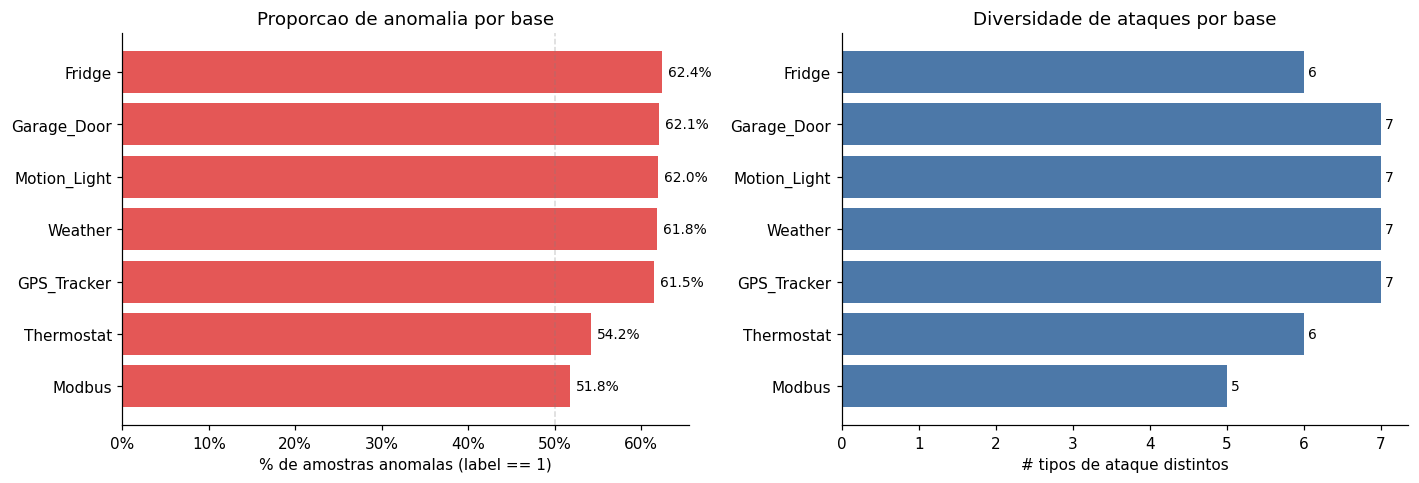

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
s = summ.sort_values('pct_attack')

ax = axes[0]
bars = ax.barh(s['device'], s['pct_attack'], color=COLOR_ATTACK)
ax.set_xlabel('% de amostras anomalas (label == 1)')
ax.set_title('Proporcao de anomalia por base')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.axvline(50, color='gray', alpha=0.3, linestyle='--', linewidth=1)
for b, v in zip(bars, s['pct_attack']):
    ax.text(v + 0.7, b.get_y() + b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=9)

ax = axes[1]
ax.barh(s['device'], s['n_attack_types'], color=COLOR_NORMAL)
ax.set_xlabel('# tipos de ataque distintos')
ax.set_title('Diversidade de ataques por base')
for i, v in enumerate(s['n_attack_types']):
    ax.text(v + 0.05, i, str(int(v)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Heatmap base × tipo de ataque

Quantas amostras de cada tipo existem em cada base. Escala log porque
`scanning` em Thermostat (61) e algumas classes minoritárias estão
ordens de grandeza abaixo das demais.

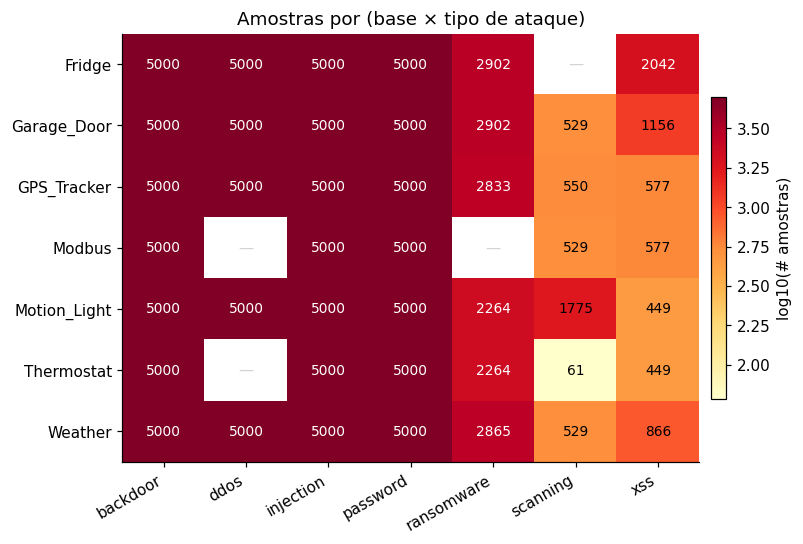

Em destaque: Thermostat/scanning = 61 amostras (pior caso pro F1 macro).
Modbus/Thermostat: sem ddos. Modbus: sem ransomware tambem.


In [ ]:
all_attacks = sorted({a for _, df in dfs.items()
                       for a in df['type'].unique() if a != 'normal'})
mat = np.zeros((len(dfs), len(all_attacks)))
for i, (device, df) in enumerate(dfs.items()):
    counts = df['type'].value_counts()
    for j, a in enumerate(all_attacks):
        mat[i, j] = counts.get(a, 0)

fig, ax = plt.subplots(figsize=(1.1 + 0.9 * len(all_attacks), 0.55 * len(dfs) + 1.2))
mat_plot = np.where(mat > 0, mat, np.nan)
im = ax.imshow(np.log10(mat_plot), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(all_attacks)))
ax.set_xticklabels(all_attacks, rotation=30, ha='right')
ax.set_yticks(range(len(dfs)))
ax.set_yticklabels(list(dfs.keys()))
for i in range(len(dfs)):
    for j in range(len(all_attacks)):
        v = int(mat[i, j])
        if v > 0:
            color = 'white' if np.log10(v) > 3.3 else 'black'
            ax.text(j, i, f'{v}', ha='center', va='center',
                    color=color, fontsize=9)
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    color='lightgray', fontsize=10)
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('log10(# amostras)')
ax.set_title('Amostras por (base × tipo de ataque)')
plt.tight_layout()
plt.show()
print('Em destaque: Thermostat/scanning = 61 amostras (pior caso pro F1 macro).')
print('Modbus/Thermostat: sem ddos. Modbus: sem ransomware tambem.')

## 5. ⚠️ Estrutura temporal: descoberta crucial

O TON_IoT foi coletado **sequencialmente**: primeiro um bloco de tráfego
normal, depois cada tipo de ataque numa janela separada. **Normal e
ataque NÃO se sobrepõem no tempo.** Implicação direta:

> ### Se o modelo usar `date` ou `time` como feature, basta saber a
> ### data pra classificar perfeitamente. Isso é **data leakage**.

O `feature_cols()` da §3 já exclui `date`/`time` de `META_COLS`, mas
**isso tem que estar documentado no relatório** — não é uma
detecção de anomalia em fluxo contínuo (como seria em IoT real); é
classificação supervisionada com classes temporalmente disjuntas.

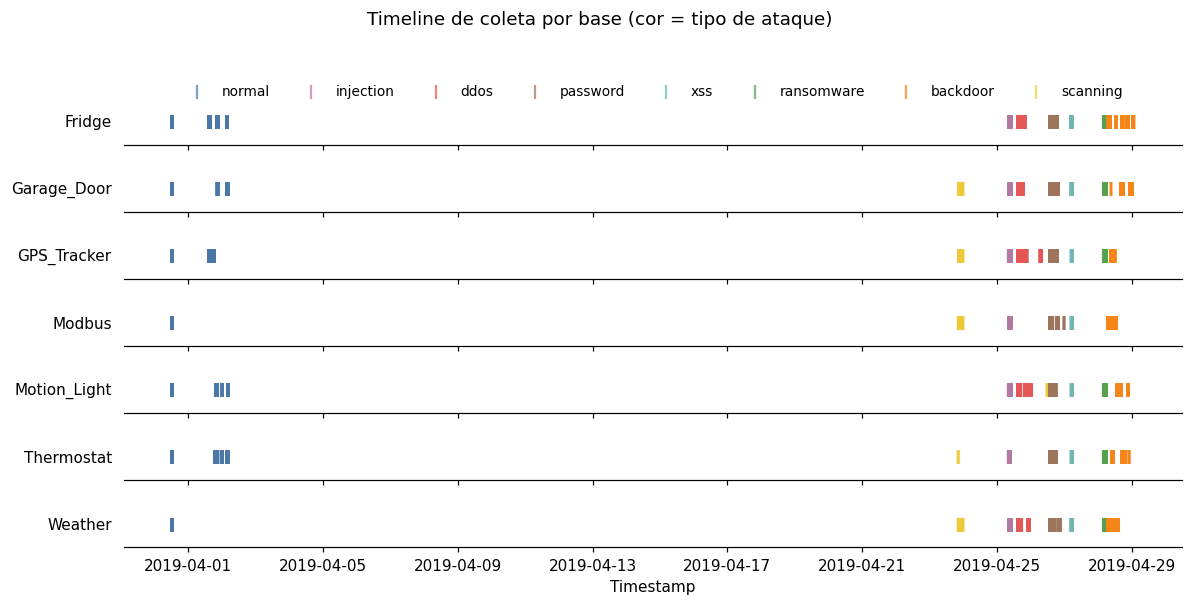

Observe: normal (azul) ocupa um bloco; cada ataque tem sua janela isolada.
Em Weather, todo o "normal" foi coletado em ~4 minutos de uma vez.


In [ ]:
def parse_ts(df):
    s = df['date'].astype(str).str.strip() + ' ' + df['time'].astype(str).str.strip()
    return pd.to_datetime(s, format='%d-%b-%y %H:%M:%S', errors='coerce')


# timeline strip plot por base: cada amostra vira um pequeno tick
# horizontal, com a cor do tipo de ataque
fig, axes = plt.subplots(len(dfs), 1, figsize=(11, 0.55 * len(dfs) + 1.5),
                         sharex=True)
axes = np.atleast_1d(axes)
for ax, (device, df) in zip(axes, dfs.items()):
    df_local = df.copy()
    df_local['_ts'] = parse_ts(df_local)
    df_local = df_local.dropna(subset=['_ts'])
    if len(df_local) > 5000:
        df_local = df_local.sample(5000, random_state=0).sort_values('_ts')
    for t in df_local['type'].unique():
        sub = df_local[df_local['type'] == t]
        ax.scatter(sub['_ts'], [0] * len(sub),
                   marker='|', s=80, alpha=0.7,
                   color=ATTACK_PALETTE.get(t, '#999999'),
                   label=t)
    ax.set_yticks([])
    ax.set_ylabel(device, rotation=0, ha='right', va='center',
                  fontsize=10, labelpad=8)
    ax.spines['left'].set_visible(False)
# legenda global usando todos os tipos vistos
handles, labels = [], []
seen = set()
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen:
            handles.append(h)
            labels.append(l)
            seen.add(l)
axes[0].legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 1.6), ncol=min(len(labels), 8),
               fontsize=9, frameon=False)
axes[-1].set_xlabel('Timestamp')
fig.suptitle('Timeline de coleta por base (cor = tipo de ataque)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
print('Observe: normal (azul) ocupa um bloco; cada ataque tem sua janela isolada.')
print('Em Weather, todo o "normal" foi coletado em ~4 minutos de uma vez.')

In [ ]:
# Range temporal compacto por base e por classe
trange = []
for device, df in dfs.items():
    df_local = df.copy()
    df_local['_ts'] = parse_ts(df_local)
    df_local = df_local.dropna(subset=['_ts'])
    n_ts = df_local['_ts']
    nor = df_local[df_local['label'] == 0]['_ts']
    atk = df_local[df_local['label'] == 1]['_ts']
    duration_normal_min = (nor.max() - nor.min()).total_seconds() / 60 if len(nor) else 0
    duration_attack_min = (atk.max() - atk.min()).total_seconds() / 60 if len(atk) else 0
    trange.append({
        'device': device,
        'normal_start': str(nor.min())[:16] if len(nor) else '-',
        'normal_dur_min': round(duration_normal_min, 1),
        'attack_start': str(atk.min())[:16] if len(atk) else '-',
        'attack_dur_h': round(duration_attack_min / 60, 1),
    })
print(pd.DataFrame(trange).to_string(index=False))

      device     normal_start  normal_dur_min     attack_start  attack_dur_h
      Fridge 2019-03-31 12:36          2367.4 2019-04-25 07:49          89.4
 Garage_Door 2019-03-31 12:41          2365.7 2019-04-23 20:20         123.6
 GPS_Tracker 2019-03-31 12:36          1785.7 2019-04-23 20:20         111.4
      Modbus 2019-03-31 12:40             3.8 2019-04-23 20:20         112.3
Motion_Light 2019-03-31 12:36          2370.0 2019-04-25 07:49          85.6
  Thermostat 2019-03-31 12:43          2363.4 2019-04-23 20:20         121.9
     Weather 2019-03-31 12:40             4.0 2019-04-23 20:20         113.7


## 6. Distribuições por feature

### 6.1 Numéricas — `normal` (azul) vs `attack` (vermelho)

Histograma normalizado. Onde as distribuições se sobrepõem fortemente,
o sinal está em **interações de features** (e aí o `addressSize` do
WNN passa a importar mais que o tamanho do termômetro).

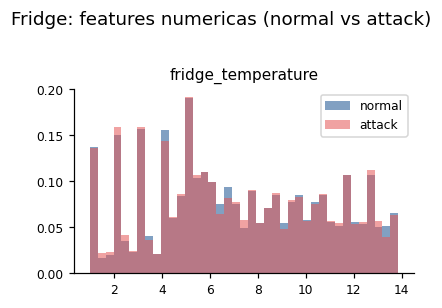

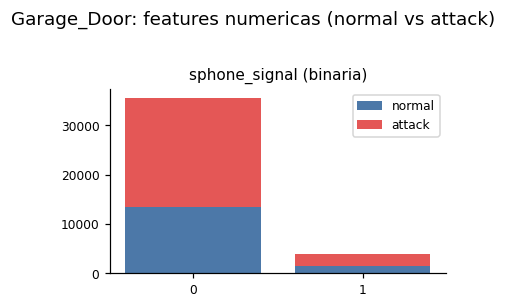

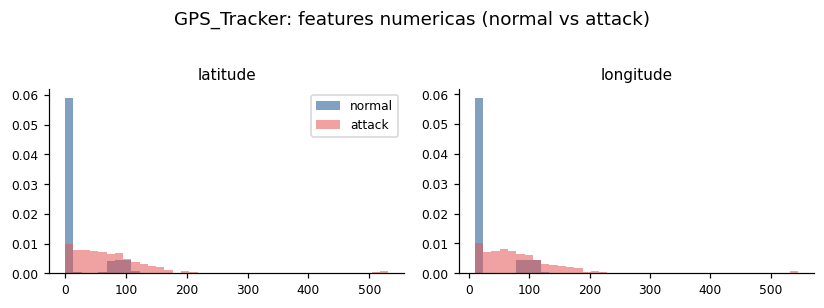

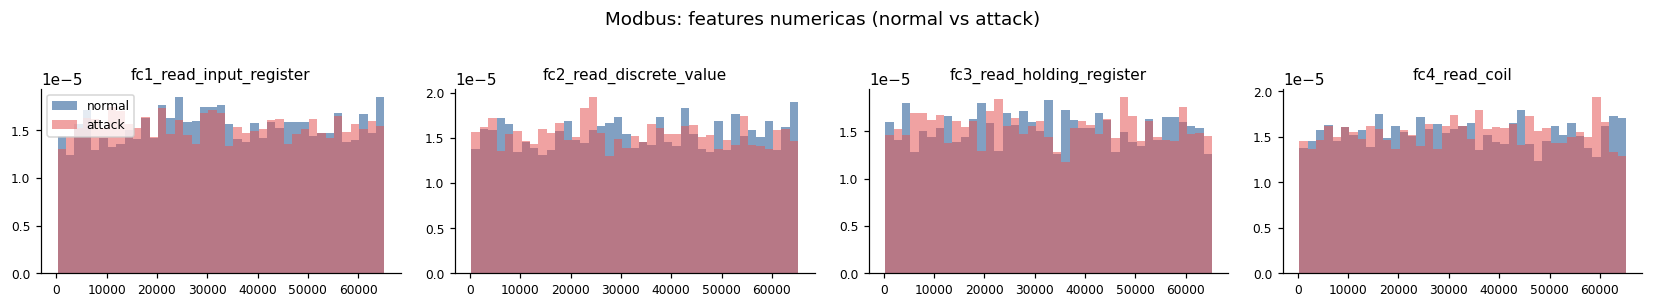

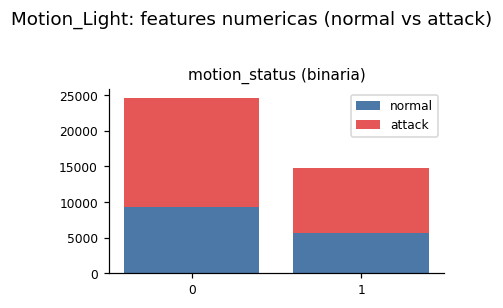

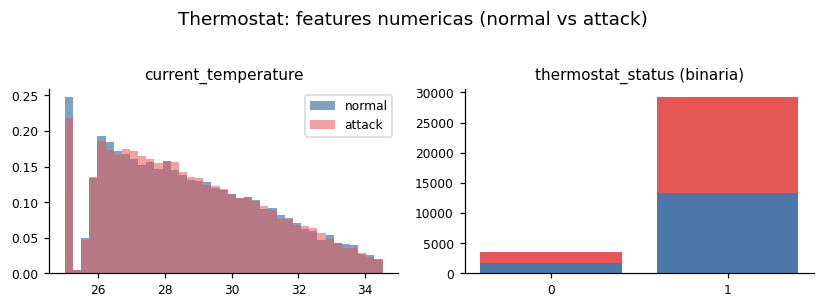

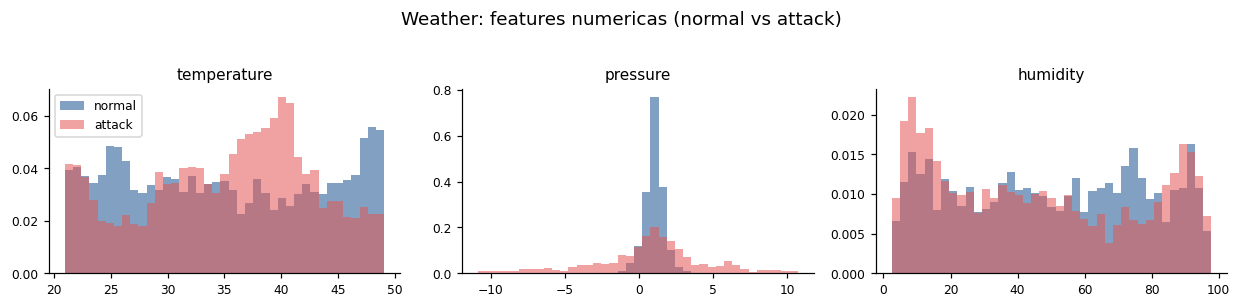

In [ ]:
def plot_numeric_features(device, df):
    num, _ = feature_cols(df)
    if not num:
        print(f'  ({device}) sem features numericas — pulando.')
        return
    ncols = min(4, len(num))
    nrows = int(np.ceil(len(num) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 2.7 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, f in zip(axes, num):
        s = df[f].dropna()
        if s.nunique() <= 2:
            counts = pd.crosstab(df[f], df['label']).reindex(columns=[0, 1], fill_value=0)
            ax.bar(counts.index.astype(str), counts[0], color=COLOR_NORMAL, label='normal')
            ax.bar(counts.index.astype(str), counts[1], color=COLOR_ATTACK,
                   bottom=counts[0], label='attack')
            ax.set_title(f'{f} (binaria)', fontsize=10)
        else:
            lo, hi = s.quantile(0.005), s.quantile(0.995)
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = float(s.min()), float(s.max())
            bins = np.linspace(lo, hi, 40)
            ax.hist(df.loc[df['label'] == 0, f].dropna(), bins=bins,
                    color=COLOR_NORMAL, alpha=0.7, label='normal', density=True)
            ax.hist(df.loc[df['label'] == 1, f].dropna(), bins=bins,
                    color=COLOR_ATTACK, alpha=0.55, label='attack', density=True)
            ax.set_title(f, fontsize=10)
        ax.tick_params(labelsize=8)
    for ax in axes[len(num):]:
        ax.set_visible(False)
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{device}: features numericas (normal vs attack)',
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


for device, df in dfs.items():
    plot_numeric_features(device, df)

### 6.2 Categóricas — barras stackeadas

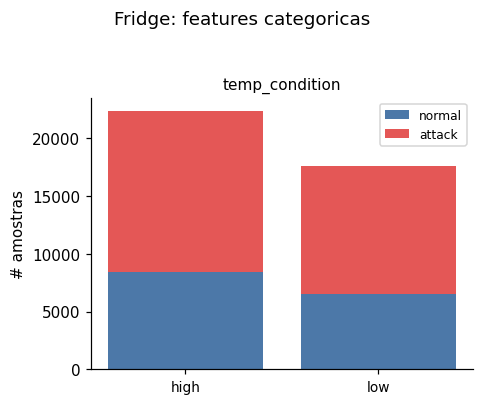

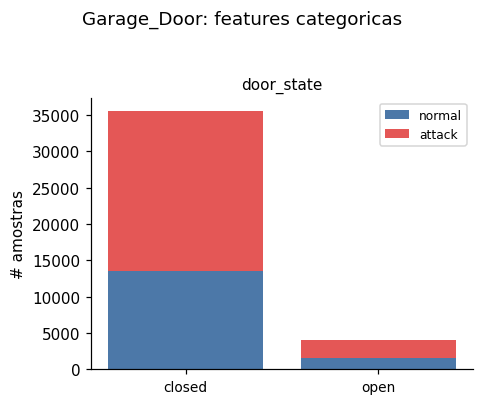

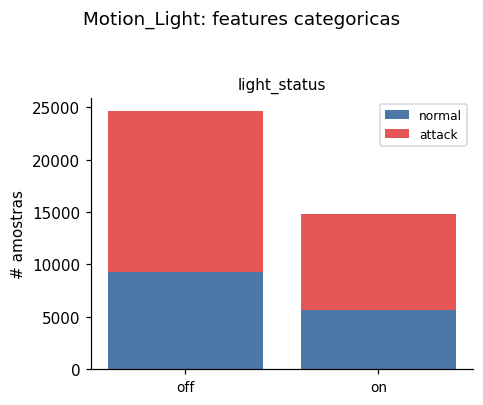

In [ ]:
def plot_categorical_features(device, df):
    _, cat = feature_cols(df)
    if not cat:
        return
    fig, axes = plt.subplots(1, len(cat), figsize=(4.5 * len(cat), 3.5))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cat):
        counts = pd.crosstab(df[c], df['label']).reindex(columns=[0, 1], fill_value=0)
        idx = counts.index.astype(str)
        ax.bar(idx, counts[0], color=COLOR_NORMAL, label='normal')
        ax.bar(idx, counts[1], bottom=counts[0], color=COLOR_ATTACK, label='attack')
        ax.set_title(f'{c}', fontsize=10)
        ax.set_ylabel('# amostras')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', labelsize=9)
    fig.suptitle(f'{device}: features categoricas', y=1.04, fontsize=12)
    plt.tight_layout()
    plt.show()


for device, df in dfs.items():
    plot_categorical_features(device, df)

## 7. Pares de features — scatter colorido

Algumas bases têm 2+ features numéricas — útil ver se a fronteira
`normal`/`attack` é separável no plano 2D. Em GPS_Tracker, latitude
× longitude é o caso mais interessante.

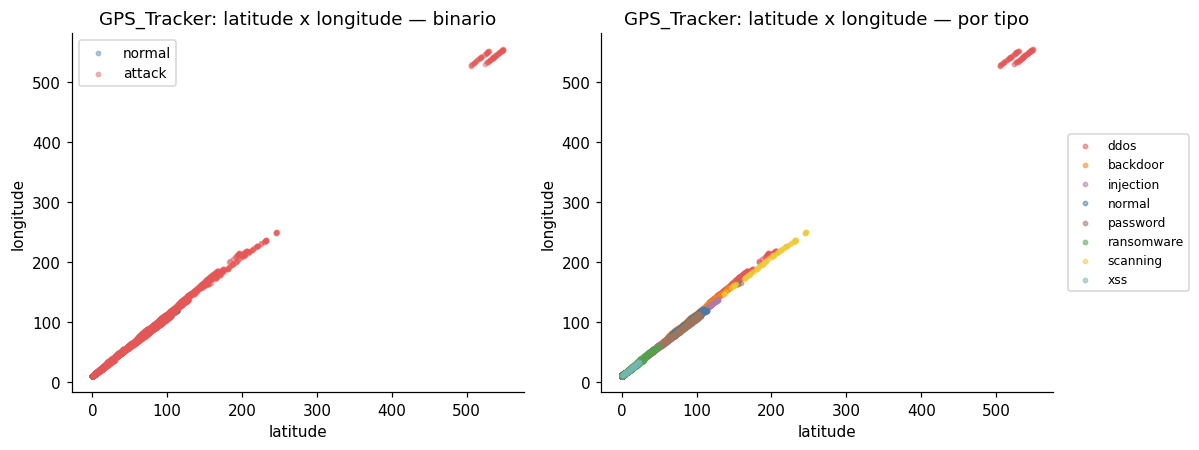

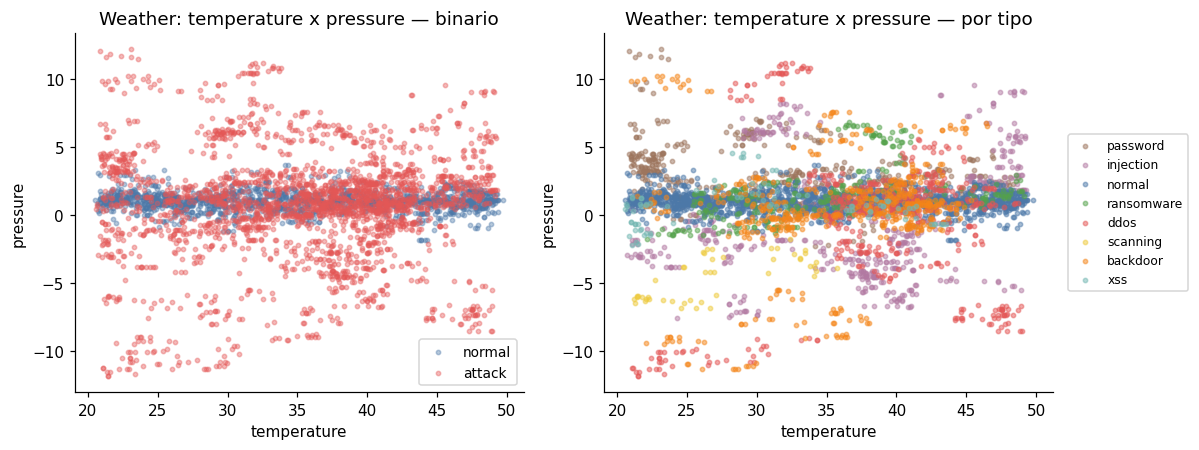

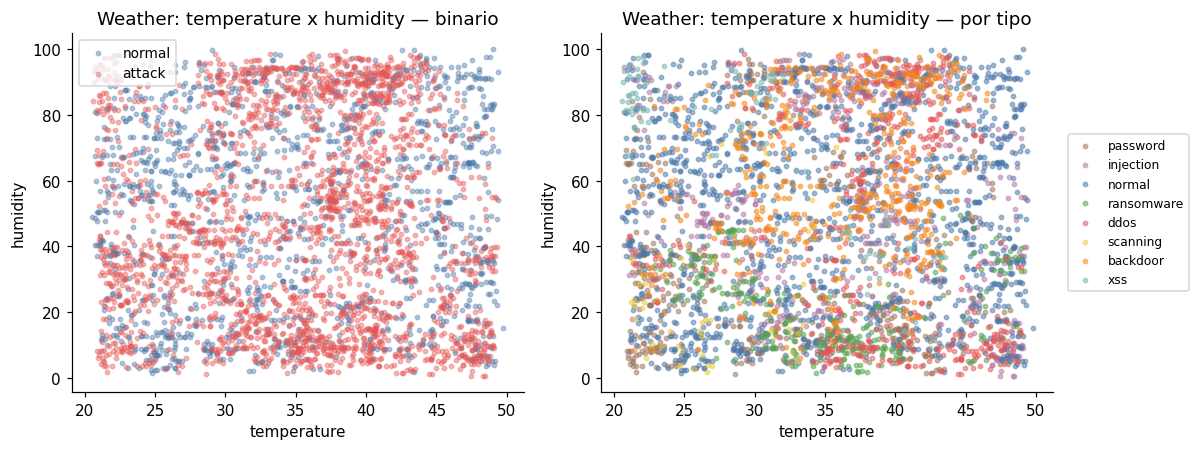

In [ ]:
def scatter_pair(device, fx, fy, subsample=4000):
    df = dfs[device]
    show = df.sample(min(subsample, len(df)), random_state=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    # esquerda: colorido por label
    ax = axes[0]
    for lbl, color, name in [(0, COLOR_NORMAL, 'normal'),
                             (1, COLOR_ATTACK, 'attack')]:
        sub = show[show['label'] == lbl]
        ax.scatter(sub[fx], sub[fy], s=8, alpha=0.4, c=color, label=name)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f'{device}: {fx} x {fy} — binario')
    ax.legend(fontsize=9)

    # direita: colorido por tipo
    ax = axes[1]
    for t in show['type'].unique():
        sub = show[show['type'] == t]
        ax.scatter(sub[fx], sub[fy], s=8, alpha=0.5,
                   c=ATTACK_PALETTE.get(t, '#999999'), label=t)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f'{device}: {fx} x {fy} — por tipo')
    ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()


scatter_pair('GPS_Tracker', 'latitude', 'longitude')
scatter_pair('Weather', 'temperature', 'pressure')
scatter_pair('Weather', 'temperature', 'humidity')

## 8. Correlações entre features numéricas contínuas

Pearson. Só pra bases com ≥ 2 features numéricas **contínuas** (descarta
binárias 0/1).

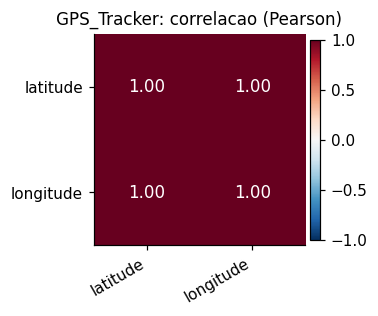

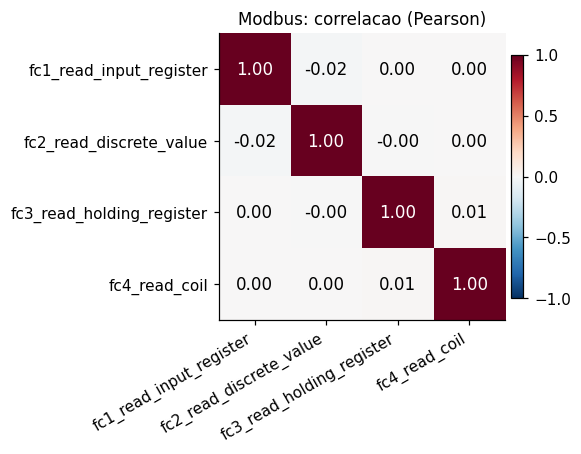

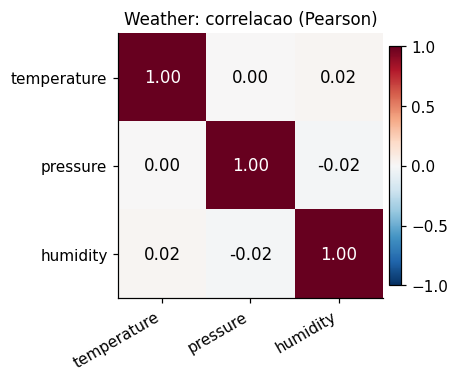

In [ ]:
def plot_corr(device, df):
    num, _ = feature_cols(df)
    feats = [f for f in num if df[f].nunique() > 2]
    if len(feats) < 2:
        return
    corr = df[feats].corr()
    side = max(3.5, 0.9 * len(feats) + 1.5)
    fig, ax = plt.subplots(figsize=(side, side * 0.85))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=10)
    for i in range(len(feats)):
        for j in range(len(feats)):
            v = corr.iloc[i, j]
            color = 'white' if abs(v) > 0.55 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=11, color=color)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(f'{device}: correlacao (Pearson)', fontsize=11)
    plt.tight_layout()
    plt.show()


for device, df in dfs.items():
    plot_corr(device, df)

## 9. Codificação binária — termômetros

WNNs leem entrada binária. As features numéricas viram bits via um dos
4 **termômetros**:

- **Simple** — thresholds uniformes em `[min, max]`. Desperdiça bits
  em caudas longas.
- **Distributive** — thresholds nos quantis dos dados. Bits onde está
  a massa.
- **Gaussian** — fita N(μ, σ), thresholds nos quantis dessa N.
- **Exponential** — fita Exp(λ), thresholds nos quantis dessa Exp.

`Distributive` e `Gaussian` tendem a ganhar em features simétricas;
`Exponential` em features muito skewed à direita.

### 9.1 Comparação visual lado-a-lado

4 termômetros × 2 features (uma simétrica, uma skewed). Tamanho fixo
em 16 bits.

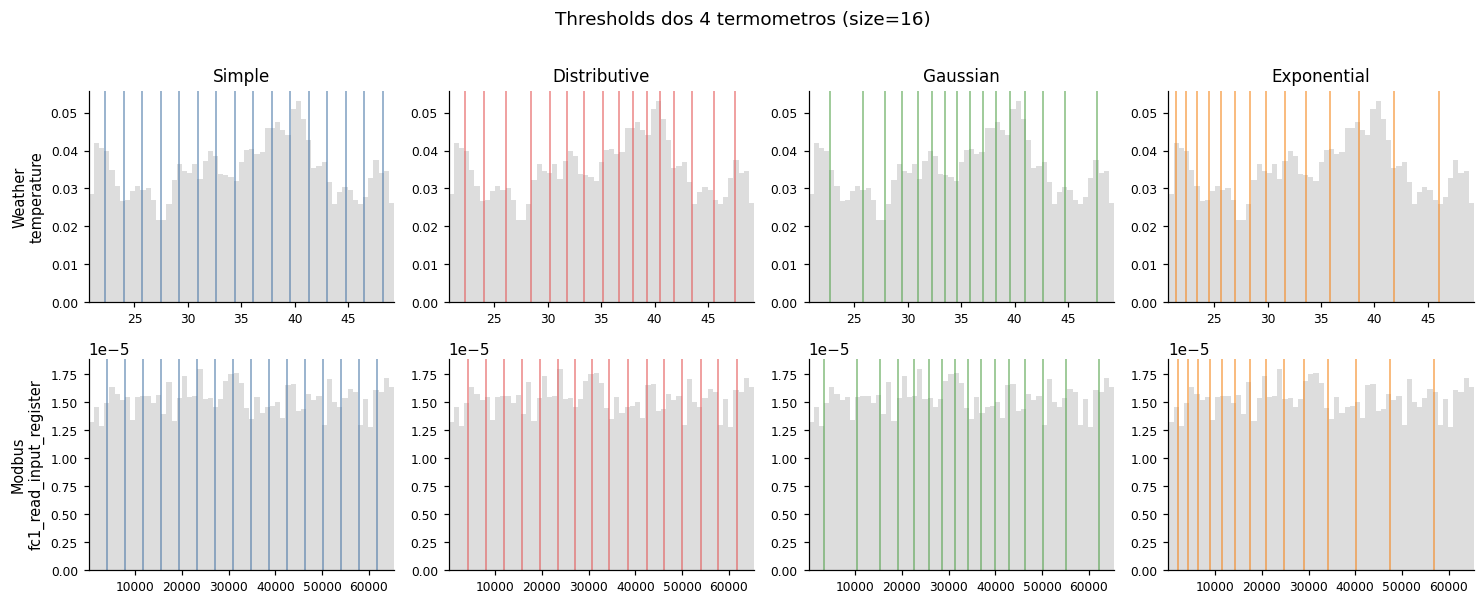

In [ ]:
from scipy.stats import norm


def simple_thresholds(values, size):
    lo, hi = np.nanmin(values), np.nanmax(values)
    return np.linspace(lo, hi, size + 2)[1:-1]


def distributive_thresholds(values, size):
    qs = np.linspace(0, 1, size + 2)[1:-1]
    return np.nanquantile(values, qs)


def gaussian_thresholds(values, size):
    mu, sigma = np.nanmean(values), np.nanstd(values)
    qs = np.linspace(0, 1, size + 2)[1:-1]
    return norm.ppf(qs, loc=mu, scale=max(sigma, 1e-12))


def exponential_thresholds(values, size):
    v = values.astype(float)
    shift = np.nanmin(v)
    shifted = v - shift
    mean = np.nanmean(shifted)
    if mean <= 0:
        mean = 1.0
    qs = np.linspace(0, 1, size + 2)[1:-1]
    return -np.log(1 - qs) * mean + shift


THERMS = [('Simple', simple_thresholds, COLOR_NORMAL),
          ('Distributive', distributive_thresholds, COLOR_ATTACK),
          ('Gaussian', gaussian_thresholds, '#54A24B'),
          ('Exponential', exponential_thresholds, '#F58518')]


def plot_thermometers(samples, size=16):
    """samples = list of (device, feature, vals) tuples."""
    fig, axes = plt.subplots(len(samples), len(THERMS),
                             figsize=(3.4 * len(THERMS), 2.7 * len(samples)),
                             sharex='row')
    if len(samples) == 1:
        axes = axes[np.newaxis, :]
    for r, (device, feat, vals) in enumerate(samples):
        lo, hi = np.nanquantile(vals, [0.001, 0.999])
        bins = np.linspace(lo, hi, 60)
        for c, (name, fn, color) in enumerate(THERMS):
            ax = axes[r, c]
            ax.hist(vals, bins=bins, color='#dddddd', density=True)
            ths = fn(vals, size)
            for t in ths:
                ax.axvline(t, color=color, alpha=0.65, linewidth=1.1)
            ax.set_xlim(lo, hi)
            ax.tick_params(labelsize=8)
            if r == 0:
                ax.set_title(name, fontsize=11)
            if c == 0:
                ax.set_ylabel(f'{device}\n{feat}', fontsize=9.5)
    fig.suptitle(f'Thresholds dos 4 termometros (size={size})',
                 y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_thermometers([
    ('Weather', 'temperature', dfs['Weather']['temperature'].values),
    ('Modbus', 'fc1_read_input_register',
     dfs['Modbus']['fc1_read_input_register'].astype(float).values),
])

Observações:

- Em `Weather/temperature` (aproximadamente simétrica): `Distributive`
  e `Gaussian` ficam praticamente iguais; `Simple` joga bits nas
  caudas que quase não têm dados; `Exponential` é inadequado.
- Em `Modbus/fc1_read_input_register` (multimodal e com cauda longa):
  `Distributive` acompanha os modos; `Gaussian` espalha errado;
  `Simple` desperdiça quase todos os bits; `Exponential` concentra
  perto do zero.

Hipótese pro sweep: `Distributive` deve dominar em quase tudo.
`Gaussian` é o default do BTHOWeN — vai ser interessante ver se essa
preferência se mantém aqui.

### 9.2 Preview do bit-pattern

5 amostras de `normal` + 5 amostras de `attack` (em Modbus, que tem
32 bits @ T8), encodadas com Distributive(8). Cada linha é um
sample; cada coluna é um bit (preto = 1, branco = 0). É **literalmente
o que a WiSARD vai ver na entrada**.

Procure padrões: bits que mudam entre as classes são os "úteis"; bits
constantes são desperdiçados.

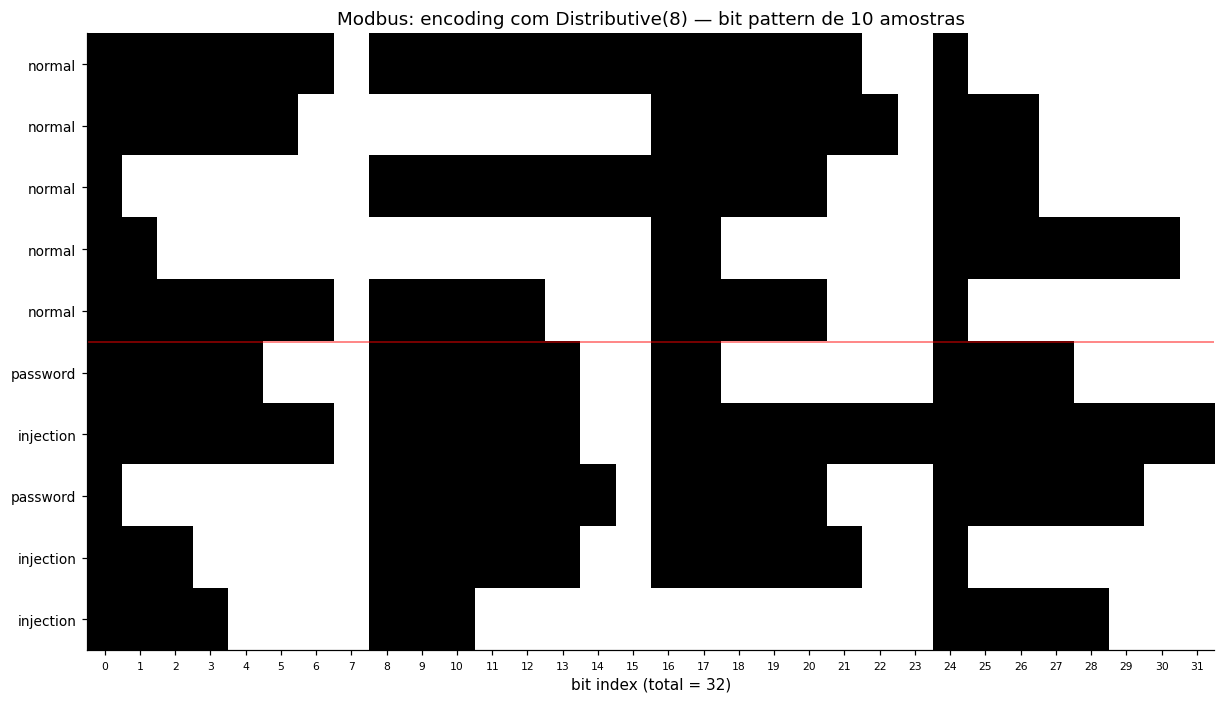

Linha vermelha separa as 5 amostras normais (em cima) das 5 de ataque (embaixo).


In [ ]:
def encode_row(row_dict, num_cols, cat_cols, cat_values, therm):
    """Encoda uma linha:
    - numericas via termometro (ja fitted)
    - categoricas binarias (2 valores) -> 1 bit (1 se valor == cat_values[c][1])
    - categoricas k-arias (k>2)        -> one-hot na ordem fixa cat_values[c]
    Retorna lista de int 0/1.
    """
    num_vals = [float(row_dict[c]) for c in num_cols]
    if num_cols:
        bi = therm.transform(num_vals)
        bits = list(bi.list())
    else:
        bits = []
    for c in cat_cols:
        v = row_dict[c]
        cats = cat_values[c]
        if len(cats) == 2:
            bits.append(1 if v == cats[1] else 0)
        else:
            for cat in cats:
                bits.append(1 if v == cat else 0)
    return bits


import wisardpkg as wp

device = 'Modbus'
df = dfs[device]
num, cat = feature_cols(df)
cat_values = {c: sorted(df[c].unique()) for c in cat}
fit_vals = df[num].astype(float).values.tolist()
therm = wp.DistributiveThermometer(8)
therm.fit(fit_vals)

normal_idx = df[df['label'] == 0].sample(5, random_state=0).index
attack_idx = df[df['label'] == 1].sample(5, random_state=0).index
labels, mat = [], []
for idx in list(normal_idx) + list(attack_idx):
    row = df.loc[idx].to_dict()
    mat.append(encode_row(row, num, cat, cat_values, therm))
    labels.append(f"{row['type']}")
mat = np.array(mat)

fig, ax = plt.subplots(figsize=(0.32 * mat.shape[1] + 1, 0.5 * mat.shape[0] + 1.5))
ax.imshow(mat, cmap='Greys', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(range(mat.shape[1]), fontsize=7)
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel(f'bit index (total = {mat.shape[1]})')
ax.set_title(f'{device}: encoding com Distributive(8) — bit pattern de 10 amostras')
ax.axhline(4.5, color='red', alpha=0.6, linewidth=1)
plt.tight_layout()
plt.show()
print('Linha vermelha separa as 5 amostras normais (em cima) das 5 de ataque (embaixo).')


### 9.3 Cobertura do grid de hiperparâmetros

Pra cada base, quais combinações `(thermoSize, addressSize)` do PLANO
geram entrada grande o suficiente pra serem válidas? Heatmap por base:
verde = válido (addressSize ≤ bits totais), vermelho = skipado.

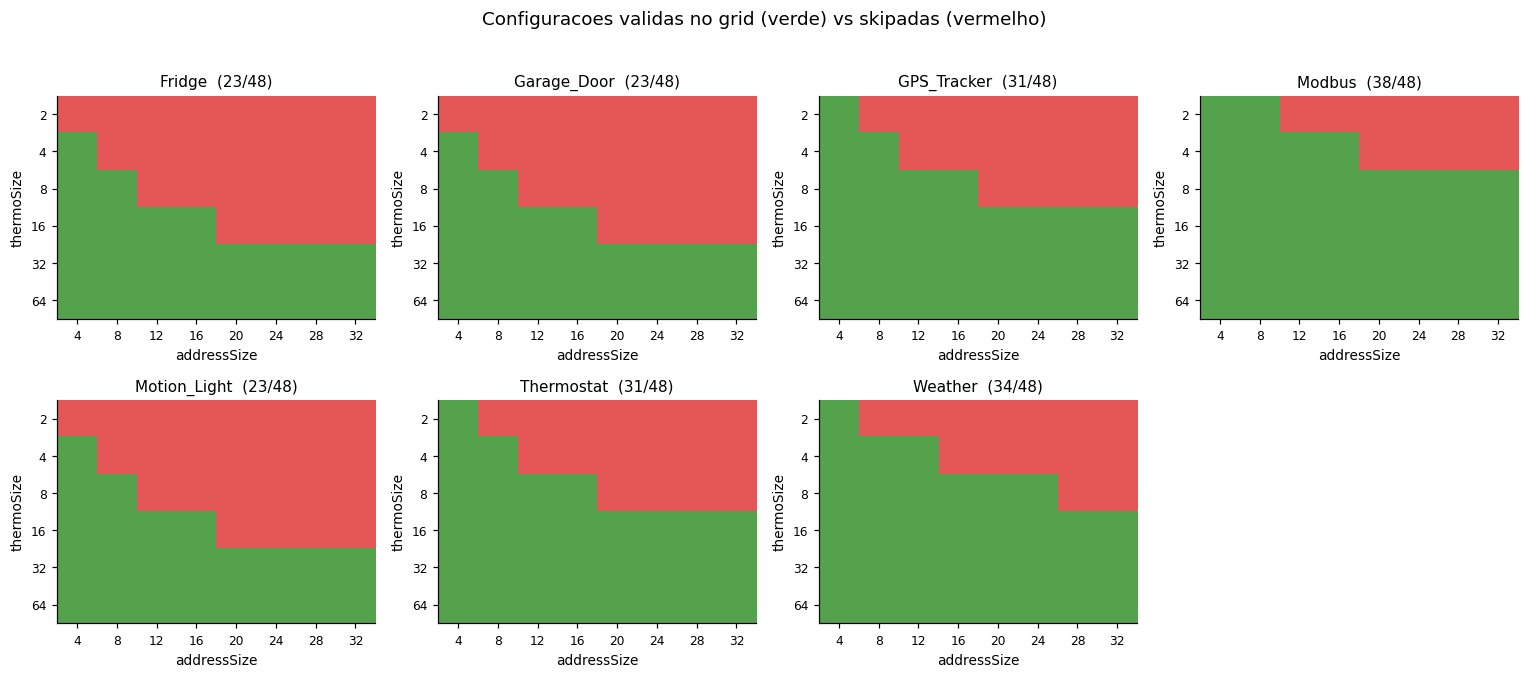

      device  valid_configs_per_thermo  total_grid
      Fridge                        23          48
 Garage_Door                        23          48
 GPS_Tracker                        31          48
      Modbus                        38          48
Motion_Light                        23          48
  Thermostat                        31          48
     Weather                        34          48

Com 4 termometros e 2 tarefas, multiplique por 8 para o total de experimentos por base.


In [ ]:
THERMO_SIZES = [2, 4, 8, 16, 32, 64]
ADDRESS_SIZES = [4, 8, 12, 16, 20, 24, 28, 32]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for ax, (device, df) in zip(axes, dfs.items()):
    num, cat = feature_cols(df)
    card = sum(cat_encoded_bits(df[c].unique()) for c in cat)
    n_num = len(num)
    valid = np.zeros((len(THERMO_SIZES), len(ADDRESS_SIZES)), dtype=int)
    for i, ts in enumerate(THERMO_SIZES):
        bits = n_num * ts + card
        for j, ad in enumerate(ADDRESS_SIZES):
            valid[i, j] = 1 if ad <= bits else 0
    cmap = LinearSegmentedColormap.from_list('vr', ['#E45756', '#54A24B'])
    ax.imshow(valid, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(ADDRESS_SIZES)))
    ax.set_xticklabels(ADDRESS_SIZES, fontsize=8)
    ax.set_yticks(range(len(THERMO_SIZES)))
    ax.set_yticklabels(THERMO_SIZES, fontsize=8)
    ax.set_xlabel('addressSize', fontsize=9)
    ax.set_ylabel('thermoSize', fontsize=9)
    ax.set_title(f'{device}  ({int(valid.sum())}/{valid.size})', fontsize=10)
for ax in axes[len(dfs):]:
    ax.set_visible(False)
fig.suptitle('Configuracoes validas no grid (verde) vs skipadas (vermelho)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
totals = []
for device, df in dfs.items():
    num, cat = feature_cols(df)
    card = sum(cat_encoded_bits(df[c].unique()) for c in cat)
    n_num = len(num)
    valid_count = sum(1 for ts in THERMO_SIZES for ad in ADDRESS_SIZES
                      if ad <= n_num * ts + card)
    totals.append({'device': device, 'valid_configs_per_thermo':
                   valid_count, 'total_grid': len(THERMO_SIZES) * len(ADDRESS_SIZES)})
print(pd.DataFrame(totals).to_string(index=False))
print('\nCom 4 termometros e 2 tarefas, multiplique por 8 para o total de experimentos por base.')


## 10. Rascunho de utilitários para o `sweep_utils.py`

Tudo daqui pra baixo é pra ser copiado pro `sweep_utils.py` que o
**coringa** vai criar. As funções abaixo materializam o schema do
PLANO §4 e devem ser chamadas pelo `02_sweep_template.ipynb` (cada
integrante adapta pro seu modelo).

A intenção é que rodar o exemplo end-to-end de §10.8 gere um JSON de
resultado **idêntico em forma** ao que cada integrante vai produzir
em massa.

### 10.1 `encode_dataset` — termômetro + one-hot

In [ ]:
import wisardpkg as wp

THERM_BUILDERS = {
    'Simple':       lambda size, mins, maxs: wp.SimpleThermometer(size, minimum=mins, maximum=maxs),
    'Distributive': lambda size, mins, maxs: wp.DistributiveThermometer(size),
    'Gaussian':     lambda size, mins, maxs: wp.GaussianThermometer(size),
    'Exponential':  lambda size, mins, maxs: wp.ExponentialThermometer(size),
}


def fit_encoder(df_train, num_cols, therm_type, size):
    """Retorna therm_obj_or_none ajustado em num_cols do treino.

    Para Simple, precisa de minimum/maximum por feature; para os outros,
    basta o fit com a matriz de treino.
    """
    if not num_cols:
        return None
    vals = df_train[num_cols].astype(float).values
    mins = vals.min(axis=0).tolist()
    maxs = vals.max(axis=0).tolist()
    therm = THERM_BUILDERS[therm_type](size, mins, maxs)
    if therm_type != 'Simple':
        therm.fit(vals.tolist())
    return therm


def cat_categories(df_train, cat_cols):
    """Para cada categorica, lista de valores unicos em ordem deterministica
    (sorted). A ordem importa: na codificacao binaria de 2 valores, '1'
    corresponde a cat_values[c][1] (segundo elemento)."""
    return {c: sorted(df_train[c].unique()) for c in cat_cols}


def encode_dataset(df, num_cols, cat_cols, cat_values, therm):
    """Encoda um dataframe inteiro em uma lista de listas de bits.

    Politica de categoricas (ver tambem cat_encoded_bits em §3):
    - 2 valores  -> 1 bit (1 se igual a cat_values[c][1])
    - >2 valores -> one-hot (k bits)
    """
    if num_cols:
        num_vals = df[num_cols].astype(float).values
        bit_rows = []
        for row in num_vals:
            bi = therm.transform(row.tolist())
            bit_rows.append(bi.list())
    else:
        bit_rows = [[] for _ in range(len(df))]
    if cat_cols:
        cat_vals_arr = df[cat_cols].values
        for i, row in enumerate(cat_vals_arr):
            for c_idx, c in enumerate(cat_cols):
                v = row[c_idx]
                cats = cat_values[c]
                if len(cats) == 2:
                    bit_rows[i].append(1 if v == cats[1] else 0)
                else:
                    bit_rows[i].extend([1 if v == cat else 0 for cat in cats])
    return bit_rows


def encoded_input_bits(n_num, cat_values, therm_size):
    cat_bits = sum(cat_encoded_bits(v) for v in cat_values.values())
    return n_num * therm_size + cat_bits


### 10.2 `make_split` — estratificado por `type`

Mesmo split é usado pras duas tarefas (binária e multi-classe) — só
muda qual coluna vira `y`.

In [ ]:
from sklearn.model_selection import train_test_split


def make_split(df, task, test_size=0.3, random_state=0):
    """
    task: 'binary' -> y = label (0/1 como string)
          'multiclass' -> y = type (string)
    Sempre estratificado por 'type' pra garantir representacao de cada
    ataque mesmo em test_size pequenos.
    """
    if task == 'binary':
        y = df['label'].astype(int).map({0: 'normal', 1: 'attack'}).values
    elif task == 'multiclass':
        y = df['type'].values
    else:
        raise ValueError(task)
    idx_train, idx_test = train_test_split(
        np.arange(len(df)),
        test_size=test_size,
        random_state=random_state,
        stratify=df['type'].values,
    )
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)
    y_train = y[idx_train]
    y_test = y[idx_test]
    return df_train, df_test, y_train, y_test

### 10.3 `compute_metrics` — match com o schema do PLANO

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix)


def compute_metrics(y_true, y_pred, y_score=None, task='binary',
                    score_classes=None):
    """Retorna (metrics_dict, confusion_matrix, labels) no formato do schema.

    Argumentos:
        y_true, y_pred: arrays de strings (mesmas classes em ambas).
        y_score: opcional. Se fornecido, calcula AUC.
            - binary: array (n,) com score da classe positiva ('attack')
              OU array (n, 2) com [score_normal, score_attack]; usamos
              a coluna correspondente a score_classes.index('attack').
            - multiclass: matriz (n, K) com score por classe na ordem
              de score_classes (lista de strings das classes).
        score_classes: lista das colunas de y_score. Necessario quando
            y_score nao for vetor 1-D.
    """
    out = {
        'accuracy':           float(accuracy_score(y_true, y_pred)),
        'precision_macro':    float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'precision_weighted': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'recall_macro':       float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_weighted':    float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'f1_macro':           float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_weighted':        float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true, y_pred)),
        'auc_roc':            None,
    }
    if y_score is not None:
        try:
            score_arr = np.asarray(y_score, dtype=float)
            if task == 'binary':
                if score_arr.ndim == 1:
                    pos_score = score_arr
                else:
                    pos_idx = score_classes.index('attack')
                    pos_score = score_arr[:, pos_idx]
                out['auc_roc'] = float(roc_auc_score(y_true == 'attack', pos_score))
            else:
                out['auc_roc'] = float(roc_auc_score(
                    y_true, score_arr, multi_class='ovr', average='macro',
                    labels=score_classes,
                ))
        except Exception as e:
            print(f'  (AUC nao calculado: {e})')
    labels = sorted(set(list(y_true) + list(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels).tolist()
    return out, cm, labels


def ranks_to_score_matrix(rank_list, classes):
    """Converte a saida wp.Wisard.rank() (lista de dicts {classe: votos})
    em matriz (n, K) de scores normalizados por linha (prob estilo softmax simples)."""
    n = len(rank_list)
    M = np.zeros((n, len(classes)), dtype=float)
    for i, d in enumerate(rank_list):
        total = sum(d.values()) or 1
        for k, cls in enumerate(classes):
            M[i, k] = d.get(cls, 0) / total
    return M


### 10.4 `measure_memory` — serializada + teórica

Serializada: tamanho do JSON do modelo em bytes.
Teórica (upper bound): `n_classes × n_rams × 2^addressSize × bytes_por_entrada`.
A serializada conta só o que foi efetivamente preenchido — a teórica
é o pior caso (todas as endereços usados).

Pra hardware embarcado, a teórica é o que importa (você tem que alocar
a RAM antes de saber o que vai vir).

In [ ]:
import math


def measure_memory(model, input_bits, address_size, n_classes,
                   bytes_per_entry=4):
    """Retorna (serializado, teorico) em bytes.

    Teorico = n_classes x ceil(input_bits / address_size) x 2^address_size
              x bytes_per_entry

    wisardpkg pad a entrada com zeros ate o proximo multiplo de
    address_size; usar ceil (nao floor) bate com o numero de RAMs que
    o C++ realmente aloca. Confirmado empiricamente: 17 bits +
    addressSize=8 produz 3 RAMs no model.json().

    bytes_per_entry=4 assume contador 32-bit (com bleaching). Pra
    contagem booleana 1 bit/entry seria suficiente; o numero aqui eh
    um upper bound razoavel pra hardware.
    """
    serialized = len(model.json().encode('utf-8'))
    n_rams = math.ceil(input_bits / address_size)
    entries_per_ram = 2 ** address_size
    theoretical = n_classes * n_rams * entries_per_ram * bytes_per_entry
    return serialized, theoretical


### 10.5 `measure_latency` — latência mediana μs/amostra

1000 inferências individuais (batch=1) — é o que importa pra edge IoT.

In [ ]:
def measure_latency(model, X_test_lists, n_iter=1000):
    """Mediana de classify() single-sample em microssegundos.

    Pre-constroi os DataSets fora do bloco temporizado pra nao incluir
    a construcao de DataSet em cada iteracao (era o problema da versao
    anterior — inflacionava ~2-5x).
    """
    if not X_test_lists:
        return None
    n = len(X_test_lists)
    # constroi pool de DataSets reutilizaveis
    pool_size = min(n, n_iter)
    pool = [wp.DataSet([X_test_lists[i]]) for i in range(pool_size)]
    # warm-up (descarta primeiras chamadas pra evitar viés de cache JIT/branch predictor)
    for ds in pool[:min(20, pool_size)]:
        _ = model.classify(ds)
    times = []
    for i in range(n_iter):
        ds = pool[i % pool_size]
        t0 = time.perf_counter_ns()
        _ = model.classify(ds)
        times.append((time.perf_counter_ns() - t0) / 1000.0)
    times.sort()
    return float(times[len(times) // 2])


### 10.6 `iter_grid` — gera só configs válidas

Pula `addressSize > input_bits` automaticamente.

In [ ]:
THERMOMETERS = ['Simple', 'Distributive', 'Gaussian', 'Exponential']


def iter_grid(n_num, cat_card,
              thermo_sizes=THERMO_SIZES,
              address_sizes=ADDRESS_SIZES,
              thermometers=THERMOMETERS):
    """Itera apenas configs com addressSize <= bits totais."""
    for th in thermometers:
        for ts in thermo_sizes:
            input_bits = n_num * ts + cat_card
            for ad in address_sizes:
                skipped = ad > input_bits
                yield {
                    'thermometer': th,
                    'thermo_size': ts,
                    'address_size': ad,
                    'input_bits': input_bits,
                    'skipped': skipped,
                }

### 10.7 `result_dict` + `save_result` — schema do PLANO

JSON exatamente como o schema da §4 do PLANO.

In [ ]:
from datetime import datetime, timezone


def result_dict(model_name, base, task, config, metrics, cm, labels,
                input_info, model_hyperparams=None, machine=None,
                skipped=False, skipped_reason=None):
    return {
        'model': model_name,
        'base': base,
        'task': task,                       # 'binary' | 'multiclass'
        'encoder': {'type': config['thermometer'], 'size': config['thermo_size']},
        'addressSize': config['address_size'],
        'model_hyperparams': model_hyperparams or {},
        'split': {'random_state': 0, 'test_size': 0.3, 'stratified': True},
        'input': input_info,
        'skipped': skipped,
        'skipped_reason': skipped_reason,
        'metrics': metrics,
        'confusion_matrix': cm,
        'labels': labels,
        'machine': machine,
        'wisardpkg_version': wp.__version__,
        'timestamp': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    }


def save_result(result, model_name, base, task):
    out_dir = RESULTS_DIR / model_name.lower()
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f'{base}__{task}.jsonl'    # uma linha por config
    with open(out_dir / fname, 'a') as f:
        f.write(json.dumps(result) + '\n')
    return out_dir / fname


### 10.8 Exemplo end-to-end: WiSARD no Fridge (binário)

Treino real com `wisardpkg.Wisard`, uma única config (Distributive/16/8).
A célula gera 1 entrada de JSON em `results/wisard/Fridge__binary.jsonl`
— exatamente o formato que cada integrante vai gerar em massa
quando rodar o sweep completo.

In [ ]:
# ============================================================
# Exemplo end-to-end: 3 configs do iter_grid, rodando WiSARD em Fridge
# (binario). Demonstra a pipeline inteira que cada integrante vai usar:
#   carrega -> split -> ajusta encoder -> encoda -> treina -> mede ->
#   AUC via rank() -> salva no schema do PLANO.
# ============================================================

base = 'Fridge'
df = dfs[base]
num, cat = feature_cols(df)
df_train, df_test, y_train, y_test = make_split(df, task='binary')

# pega 3 configs do grid pra demonstrar variacao real:
#  - 1 ruim (thermo pequeno + address pequeno),
#  - 1 razoavel (intermediario),
#  - 1 que satura o address (addressSize >= input_bits).
demo_configs = [
    {'thermometer': 'Distributive', 'thermo_size': 4,  'address_size': 4},
    {'thermometer': 'Distributive', 'thermo_size': 16, 'address_size': 8},
    {'thermometer': 'Distributive', 'thermo_size': 16, 'address_size': 16},
]

# limpa runs anteriores deste arquivo (jsonl agrupa todas as configs)
out_dir = RESULTS_DIR / 'wisard'
out_dir.mkdir(parents=True, exist_ok=True)
fout = out_dir / f'{base}__binary.jsonl'
if fout.exists():
    fout.unlink()

cat_values = cat_categories(df_train, cat)
cat_bits = sum(cat_encoded_bits(v) for v in cat_values.values())
classes = ['attack', 'normal']   # ordem fixa pra colunas de score

results_table = []
for config in demo_configs:
    therm = fit_encoder(df_train, num, config['thermometer'], config['thermo_size'])
    X_train = encode_dataset(df_train, num, cat, cat_values, therm)
    X_test  = encode_dataset(df_test,  num, cat, cat_values, therm)
    input_bits = encoded_input_bits(len(num), cat_values, config['thermo_size'])

    ds_train = wp.DataSet(X_train, list(y_train))
    ds_test  = wp.DataSet(X_test)

    clf = wp.Wisard(config['address_size'])
    t0 = time.perf_counter()
    clf.train(ds_train)
    train_time_s = time.perf_counter() - t0

    y_pred = np.array(clf.classify(ds_test))
    # scores via rank() — votos por classe (normalizados linha-a-linha)
    rank_out = clf.rank(ds_test)
    y_score = ranks_to_score_matrix(rank_out, classes)

    metrics, cm, labels = compute_metrics(
        y_test, y_pred, y_score=y_score, task='binary', score_classes=classes,
    )
    ser, theo = measure_memory(clf, input_bits, config['address_size'], n_classes=2)
    lat = measure_latency(clf, X_test[:200], n_iter=500)
    metrics['memory_bytes_serialized']  = int(ser)
    metrics['memory_bytes_theoretical'] = int(theo)
    metrics['train_time_s']             = round(train_time_s, 4)
    metrics['inference_latency_us']     = round(lat, 2)

    res = result_dict(
        'WiSARD', base, 'binary', config, metrics, cm, labels,
        input_info={
            'n_features_num': len(num),
            'n_features_cat': len(cat),
            'cat_bits': cat_bits,
            'bits_total': input_bits,
        },
        model_hyperparams={'bleaching': False},
        machine='local-dev',
    )
    save_result(res, 'WiSARD', base, 'binary')
    results_table.append({
        'thermo': config['thermometer'],
        'size':   config['thermo_size'],
        'addr':   config['address_size'],
        'bits':   input_bits,
        'acc':    round(metrics['accuracy'], 3),
        'f1m':    round(metrics['f1_macro'], 3),
        'auc':    round(metrics['auc_roc'], 3) if metrics['auc_roc'] is not None else None,
        'mem_ser_KB': round(ser / 1024, 1),
        'mem_theo_KB': round(theo / 1024, 1),
        'latency_us': round(lat, 2),
    })

print(pd.DataFrame(results_table).to_string(index=False))
print(f'\nResultados em {fout}  (1 linha JSON por config)')


      thermo  size  addr  bits   acc   f1m   auc  mem_ser_KB  mem_theo_KB  latency_us
Distributive     4     4     5 0.533 0.502 0.502         0.8          0.2        0.69
Distributive    16     8    17 0.578 0.473 0.496         1.5          6.0        0.79
Distributive    16    16    17 0.572 0.478 0.501         1.6       1024.0        0.78

Resultados em results/wisard/Fridge__binary.jsonl  (1 linha JSON por config)


**O que esse exemplo demonstra**:

1. `clean_df` foi aplicada (na §1, em todas as bases).
2. `feature_cols` separou as features corretamente.
3. `make_split` fez split estratificado.
4. `fit_encoder` ajustou o termômetro **só no treino** — evita leakage
   do teste no encoder.
5. `encode_dataset` produziu uma matriz binária.
6. WiSARD treinou, classificou, mediu memória e latência.
7. `result_dict` + `save_result` produziram um JSON exatamente no
   schema do PLANO §4, em `results/wisard/Fridge__binary.jsonl`.

**Pro sweep completo**, o integrante envolve isso em um loop sobre
`iter_grid` (§10.6) e sobre `task ∈ {binary, multiclass}`. Skipa as
configs com `skipped=True`. Salva tudo num único JSONL por base.

## 11. Próximos passos

1. **Coringa** transcreve §10.1–§10.7 pra `notebooks/toniot/sweep_utils.py`
   e escreve `02_sweep_template.ipynb` com o loop sobre `iter_grid` ×
   tarefas. O exemplo de §10.8 vira `if __name__ == '__main__'` do
   `sweep_utils.py` para auto-teste.
2. Cada integrante (WiSARD, ClusWiSARD, BloomWiSARD, BTHOWeN, ULEEN)
   copia o template, adapta a parte do modelo (mantendo a interface
   `train(ds) -> classify(ds)`), e roda nas 7 bases × 2 tarefas.
3. Resultados em `results/<modelo>/<base>__<task>.jsonl` (jsonl: 1
   linha por config).
4. Coringa consolida em `03_analise_final.ipynb` — tabelas, matrizes
   de confusão dos top-3 por base, e a fronteira de Pareto cross-model
   `(memória, F1 macro)`.
5. Apresentação → relatório técnico.

### Dúvidas frequentes esperadas

- **"AddressSize=4 é muito pequeno?"** — Não pra essas bases pobres
  (Fridge tem só 18 bits @ T16; addressSize alto mata o número de
  RAMs). O grid varre, deixa os dados falarem.
- **"Posso usar features derivadas (e.g., hora do dia, diff de
  amostra anterior)?"** — Não nesse trabalho. Vamos no schema fixo
  pra comparação cross-model honesta. Features derivadas viram um
  experimento de extensão se sobrar tempo.
- **"Multi-classe em base sem `ddos`?"** — OK, `make_split` estratifica
  por `type` então cada base treina/testa com seu próprio conjunto de
  classes. A matriz de confusão vai mostrar o que faltou.
